# Load packages

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import random
from dataclasses import dataclass
from pathlib import Path
from anndata import AnnData

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import torch
import yaml

In [17]:
# Add parent directory to path
os.chdir("/workspace/STAIG/src")

# Import STAIG
from staig.adata_processing import LoadBatch10xAdata, LoadSingle10xAdata
from staig.stagm import STAGM

# Load data

In [18]:
# Define classes used thru script


@dataclass
class yml_config:
    dataset: str
    slide: str
    config: str
    label: bool

In [74]:
# Define the base "/Dataset" folder
data_path = Path("./Dataset")

args = yml_config(
    dataset="DLPFC",
    slide="151676",
    config="train_img_config.yaml",
    label=True,
)

# Load dataset configuration
config = yaml.load(Path(args.config).read_text(), Loader=yaml.SafeLoader)[
    151673
]

# Path to targe slide
slide_path = data_path / args.dataset / args.slide
slide_path

PosixPath('Dataset/DLPFC/151676')

In [75]:
config

{'seed': 39788,
 'learning_rate': 0.0005,
 'num_hidden': 64,
 'num_proj_hidden': 64,
 'activation': 'prelu',
 'base_model': 'GCNConv',
 'num_layers': 1,
 'drop_feature_rate_1': 0.1,
 'drop_feature_rate_2': 0.2,
 'tau': 35,
 'num_epochs': 300,
 'weight_decay': 1e-05,
 'num_clusters': 7,
 'num_gene': 3000,
 'num_neigh': 5,
 'k': 80}

In [76]:
# # Set seed from yaml_config file
# torch.manual_seed(config["seed"])
# np.random.seed(config["seed"])

# # Set torch to deterministic for experiment reproducibility
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(config["seed"])
#     torch.cuda.manual_seed_all(config["seed"])
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False
# random.seed(config["seed"])

# torch.use_deterministic_algorithms(True)

# # Configure cuBLAS memory allocation to 4096MB 8 workspaces
# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [77]:
os.chdir("/workspace/")
adata: AnnData = LoadSingle10xAdata(
    path=str(slide_path),
    n_neighbors=config["num_neigh"],
    n_top_genes=config["num_gene"],
    image_emb=True,
    label=args.label,
).run()

Calculating edge_probabilities: 100%|██████████| 3431/3431 [00:00<00:00, 81574.14it/s]

adata load done


# Train

In [78]:
# Set staig configuration from config_yml
stagm = STAGM(args=args, config=config, single=False)
stagm.adata = adata

In [79]:
# Train model
stagm.train()

=== prepare for training ===
=== train ===


  0%|          | [00:00<?, ?it/s]

100%|██████████| [00:29<00:00, 10.14it/s]


In [80]:
# Eval model
stagm.eva() 

=== load ===

========== Model Diagnostics ==========
  Total parameters:     200,385
  Trainable parameters: 200,385
  Model weight size:    1.53 MB
  Peak GPU memory:      1416.67 MB
  Training time:        0m 29.6s  (29.6s total)
  Time per epoch:       98.6 ms

  Loss curve:            first=8.8027  last=8.7776  min=8.7775  max=8.8027

  Embedding shape:      (3431, 64)
  Embedding norm — mean=8.9591  std=3.6062  min=3.0738  max=21.8544

embedding generated, go clustering


In [81]:
stagm.cluster(args.label)

Searching resolution...
Cluster count 11 is too large, adjusting end downward...
Cluster count 7 is too small, adjusting end upward...
resolution=0.2650, cluster number=11
resolution=0.2600, cluster number=11
resolution=0.2550, cluster number=11
resolution=0.2500, cluster number=10
resolution=0.2450, cluster number=10
resolution=0.2400, cluster number=10
resolution=0.2350, cluster number=10
resolution=0.2300, cluster number=10
resolution=0.2250, cluster number=9
resolution=0.2200, cluster number=9
resolution=0.2150, cluster number=8
resolution=0.2100, cluster number=8
resolution=0.2050, cluster number=8
resolution=0.2000, cluster number=7
ARI: 0.5195
resolution=0.1950, cluster number=7
ARI: 0.5195
resolution=0.1900, cluster number=8
resolution=0.1850, cluster number=8
resolution=0.1800, cluster number=8
resolution=0.1750, cluster number=7
ARI: 0.4411
resolution=0.1700, cluster number=7
ARI: 0.4560
resolution=0.1650, cluster number=7
ARI: 0.4560
resolution=0.1600, cluster number=7
ARI: 

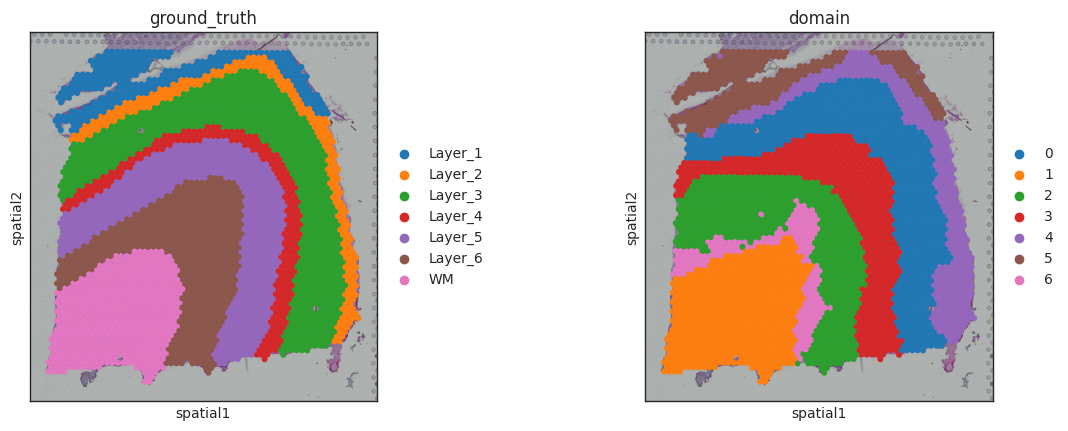

In [82]:
stagm.draw_spatial()